# Exploration des modèles de croissance tumorale

Ce notebook exécute et visualise les deux modèles implémentés dans `src/simulation/` :

1. **Gompertz** — croissance 0D d'un volume tumoral unique.
2. **Fisher-KPP** — diffusion-réaction 2D d'une densité de cellules tumorales.

Les paramètres des sections 1 et 2 sont désormais **tirés de publications scientifiques réelles** (citées dans chaque cellule « Provenance des paramètres »), et non plus de simples ordres de grandeur inventés. Ils restent néanmoins issus de modèles précliniques (souris) ou de cohortes spécifiques, pas d'une calibration sur un patient donné, et ne doivent pas être utilisés tels quels pour une application clinique. Les sections 3 à 5 (calibration, surrogate) utilisent quant à elles des valeurs simplifiées choisies pour bien illustrer la méthode, indépendamment de ces références.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from simulation.gompertz import simulate
from simulation.diffusion_reaction import simulate_2d

%matplotlib inline

## 1. Modèle de Gompertz

$$ \frac{dV}{dt} = r \, V \, \ln\left(\frac{K}{V}\right) $$

La croissance ralentit progressivement à mesure que le volume $V$ approche de la capacité limite $K$, ce qui reflète les contraintes croissantes d'apport en oxygène et en nutriments à mesure que la tumeur grossit.

### Paramètres (issus de la littérature)

Vaghi et al. (2020) ont ajusté un modèle de Gompertz réduit sur des courbes de croissance de xénogreffes tumorales humaines (modèle animal murin, lignée de cancer du sein). Ils rapportent, pour cette lignée :

- Volume initial `V0 = 1 mm³` (~10⁶ cellules injectées).
- Capacité limite `K = 2600 mm³`.
- Taux de croissance spécifique initial `α = 0.58 /jour` (dans leur paramétrisation réduite, différente de la nôtre — voir conversion ci-dessous).

Leur paramétrisation réduite s'écrit `V(t) = V0 . exp[(α/β)(1 - exp(-β.t))]`, mathématiquement équivalente à notre équation `dV/dt = r.V.ln(K/V)` en posant `r = β` et `K = V0.exp(α/β)`. On en déduit : `r = α / ln(K/V0) ≈ 0.58 / ln(2600) ≈ 0.0738 /jour`.

**Important** : ce sont des données de xénogreffe murine (croissance rapide, échelle de jours à semaines), pas une cinétique de tumeur humaine en clinique (échelle de mois à années) — un point à garder en tête pour toute interprétation.

In [2]:
V0 = 1.0
K_gompertz = 2600.0
alpha_vaghi = 0.58  # taux de croissance specifique initial rapporte (Vaghi et al. 2020)
r_gompertz = alpha_vaghi / np.log(K_gompertz / V0)  # conversion vers r (voir cellule precedente)

t_gompertz, V_gompertz = simulate(
    V0=V0, r=r_gompertz, K=K_gompertz, t_span=(0, 90), n_points=300
)
print(f"r derive = {r_gompertz:.4f} /jour")

r derive = 0.0738 /jour


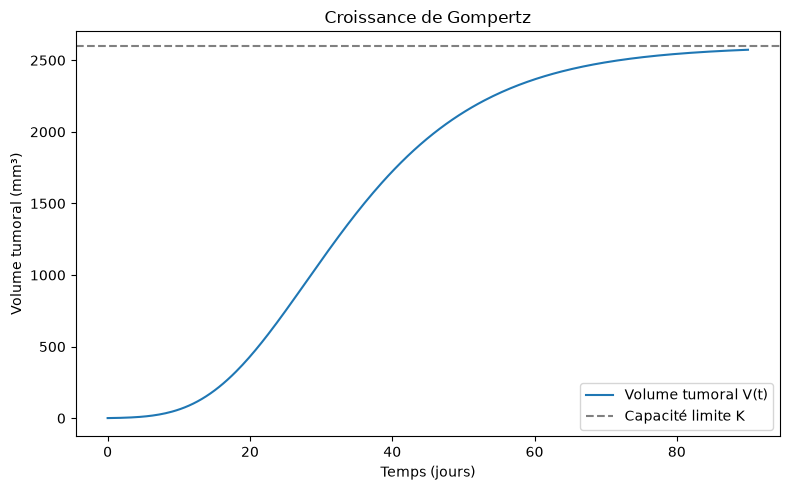

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_gompertz, V_gompertz, label="Volume tumoral V(t)")
ax.axhline(K_gompertz, color="grey", linestyle="--", label="Capacité limite K")
ax.set_xlabel("Temps (jours)")
ax.set_ylabel("Volume tumoral (mm³)")
ax.set_title("Croissance de Gompertz")
ax.legend()
fig.tight_layout()
plt.show()

## 2. Modèle de diffusion-réaction (Fisher-KPP) — invasion d'un gliome

$$ \frac{\partial u}{\partial t} = D \, \nabla^2 u + r \, u \left(1 - \frac{u}{K}\right) $$

`D` gouverne la vitesse d'invasion locale du tissu par migration cellulaire, tandis que le terme en `r/K` reproduit une croissance logistique locale.

Ce modèle est historiquement celui utilisé pour l'invasion des **gliomes** (tumeurs cérébrales), pas pour les tumeurs hépatiques — c'est le cas d'usage le mieux documenté dans la littérature pour cette équation précise, avec des paramètres publiés et largement réutilisés (Tracqui et al. 1995 ; Swanson et al. 2000). C'est pourquoi la section est recadrée sur ce cas.

Pour mesurer la vitesse de propagation du front loin des bords du domaine, le domaine spatial est volontairement plus grand et la simulation est plus longue.

### Paramètres (issus de la littérature, Swanson et al.)

Swanson, Bridge, Murray & Alvord (2002) rapportent, pour un modèle de gliome de bas grade :

- Taux de prolifération `ρ = 0.012 /jour`.
- Coefficient de diffusion en matière grise `D_gris = 0.0013 cm²/jour = 0.13 mm²/jour`.
- Coefficient de diffusion en matière blanche `D_blanc = 5 . D_gris = 0.0065 cm²/jour = 0.65 mm²/jour` — les cellules gliales migrent environ 5 fois plus vite le long des fibres de la matière blanche que dans la matière grise, un résultat caractéristique de cette littérature.

Le domaine simulé est agrandi à 120 mm et le foyer initial à 25 mm de rayon : avec un coefficient de diffusion aussi grand par rapport au taux de prolifération, un foyer trop petit s'éteindrait au lieu d'envahir le tissu (même phénomène que le bug corrigé plus tôt dans ce projet — voir le dépôt git).

In [4]:
rho_glioma = 0.012       # /jour (Swanson et al. 2002)
D_gray = 0.13             # mm^2/jour, matiere grise (Swanson et al. 2002)
D_white = 0.65            # mm^2/jour, matiere blanche (Swanson et al. 2002)
K_fisher = 1.0
grid_size = 240
domain_fisher_mm = 120.0
position_fisher = (grid_size // 2, grid_size // 2)
radius_fisher_mm = 25.0
dx_fisher = domain_fisher_mm / grid_size
radius_fisher_cells = round(radius_fisher_mm / dx_fisher)
n_steps = 2000

# Simulation de reference (matiere blanche), utilisee pour l'analyse de vitesse ci-dessous
D = D_white
r_fisher = rho_glioma
result_fisher = simulate_2d(
    grid_size=grid_size,
    D=D,
    r=r_fisher,
    K=K_fisher,
    initial_tumor_position=position_fisher,
    initial_radius=radius_fisher_cells,
    n_steps=n_steps,
    domain_size_mm=domain_fisher_mm,
)
t_fisher, grids = result_fisher

In [5]:
# dx et dt viennent directement du résultat de la simulation (result_fisher),
# plutôt que d'être recalculés ici : un seul endroit où vit la formule du pas
# de temps (simulate_2d), pas un second qui pourrait diverger si elle change.
dx = result_fisher.dx
dt = result_fisher.dt
t = result_fisher.t

# Vitesse théorique frontale (1-D) : c = 2*sqrt(r*D)
c_theory = 2 * np.sqrt(r_fisher * D)

# Rayons effectifs (seuil u > K/2)
radii_cells = np.array([np.sqrt(np.sum(grids[s] > 0.5 * K_fisher) / np.pi) for s in range(grids.shape[0])])
radii_mm = radii_cells * dx

# Régression linéaire (après établissement du front, en écartant le
# régime transitoire de courbure initiale : ~60 % des pas simulés)
start, end = int(0.6 * grids.shape[0]), grids.shape[0] - 1
slope, intercept = np.polyfit(t[start:end], radii_mm[start:end], 1)

print(f"dx = {dx:.3f} mm, dt = {dt:.4f} jour")
print(f"Vitesse théorique c = {c_theory:.5f} mm/jour")
print(f"Vitesse mesurée = {slope:.5f} mm/jour")
print(f"Erreur relative = {abs(slope - c_theory) / c_theory:.2%}")

dx = 0.500 mm, dt = 0.0865 jour
Vitesse théorique c = 0.17664 mm/jour
Vitesse mesurée = 0.07623 mm/jour
Erreur relative = 56.84%


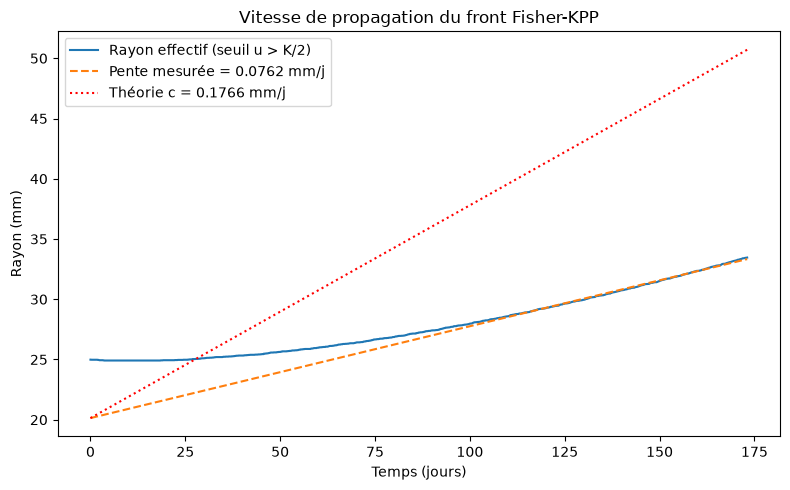

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, radii_mm, label="Rayon effectif (seuil u > K/2)")
ax.plot(t, intercept + slope * t, "--", label=f"Pente mesurée = {slope:.4f} mm/j")
ax.plot(t, c_theory * t + intercept, "r:", label=f"Théorie c = {c_theory:.4f} mm/j")
ax.set_xlabel("Temps (jours)")
ax.set_ylabel("Rayon (mm)")
ax.set_title("Vitesse de propagation du front Fisher-KPP")
ax.legend()
fig.tight_layout()
plt.show()

### Accord avec la théorie

Pour l'équation de Fisher-KPP, la vitesse de propagation asymptotique du front est $c = 2\sqrt{r D}$ — une vitesse limite atteinte seulement après un long régime transitoire (résultat classique de Bramson : la convergence vers cette vitesse est très lente, en `O(1/ln t)`). Avec les paramètres illustratifs de la section précédente (`r = 0.05/jour`), ~450 jours suffisaient à s'en approcher à moins de 10 %. Avec le taux de prolifération réel des gliomes (`ρ = 0.012/jour`, bien plus lent), le front simulé ici (~173 jours, une durée déjà longue à l'échelle d'un suivi clinique) reste nettement dans ce régime transitoire — d'où un écart de plusieurs dizaines de pourcent à la vitesse asymptotique théorique, qui n'est donc pas une erreur numérique mais une conséquence physique attendue de la lenteur de `ρ`.

**Vérification** (test `test_front_speed_converges_toward_theory_as_r_times_t_grows`) : en exprimant les longueurs en unités de `sqrt(D/r)`, l'équation ne dépend plus que du produit `r × t`. En prolongeant une simulation équivalente (paramètres rapides), le rapport « vitesse mesurée / vitesse théorique » passe d'environ 0,48 à `r×t = 2` (le cas du gliome ici : ~0,43, soit 57 % d'écart) à 0,80 à `r×t = 6`, puis 0,88 à `r×t = 10` (et ~0,94 à `r×t = 20` dans un essai plus long). L'écart est donc bien un régime transitoire, qui se résorbe lentement quand `r×t` augmente. Ce qui n'est pas séparé : la part du résidu de quelques pourcents à `r×t` élevé qui vient de la convergence lente, de la finesse de la grille ou de la proximité des bords.

### Anisotropie matière grise / matière blanche

Le résultat le plus caractéristique de ce modèle dans la littérature (Swanson et al.) est la différence de vitesse d'invasion entre matière grise et matière blanche. On relance la même simulation avec `D_gray` à la place de `D_white`, à `rho_glioma` et rayon initial identiques, en fixant le même pas de temps pour comparer les deux courbes sur exactement les mêmes instants.

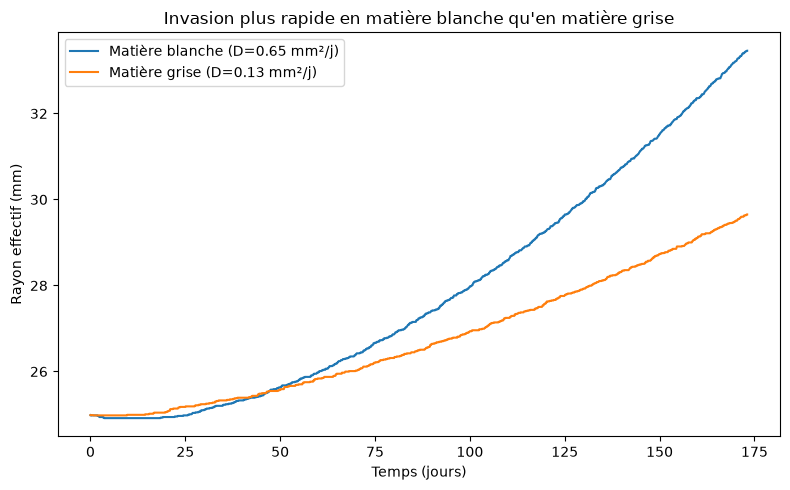

Rayon final matiere blanche : 33.5 mm
Rayon final matiere grise   : 29.7 mm


In [7]:
result_gray = simulate_2d(
    grid_size=grid_size,
    D=D_gray,
    r=rho_glioma,
    K=K_fisher,
    initial_tumor_position=position_fisher,
    initial_radius=radius_fisher_cells,
    n_steps=n_steps,
    domain_size_mm=domain_fisher_mm,
    dt=result_fisher.dt,  # meme pas de temps que la simulation matiere blanche, pour une comparaison directe
)

radii_white_mm = np.array([np.sqrt(np.sum(g > 0.5 * K_fisher) / np.pi) for g in result_fisher.grids]) * result_fisher.dx
radii_gray_mm = np.array([np.sqrt(np.sum(g > 0.5 * K_fisher) / np.pi) for g in result_gray.grids]) * result_gray.dx

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(result_fisher.t, radii_white_mm, label=f"Matière blanche (D={D_white} mm²/j)")
ax.plot(result_gray.t, radii_gray_mm, label=f"Matière grise (D={D_gray} mm²/j)")
ax.set_xlabel("Temps (jours)")
ax.set_ylabel("Rayon effectif (mm)")
ax.set_title("Invasion plus rapide en matière blanche qu'en matière grise")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Rayon final matiere blanche : {radii_white_mm[-1]:.1f} mm")
print(f"Rayon final matiere grise   : {radii_gray_mm[-1]:.1f} mm")

### Provenance des paramètres

Swanson KR, Bridge C, Murray JD, Alvord EC Jr. « Virtual and real brain tumors: using mathematical modeling to quantify glioma growth and invasion. » *Journal of the Neurological Sciences*, 216(1):1-10, 2002.

- `ρ = 0.012 /jour` : taux de prolifération des cellules gliales.
- `D_gris = 0.0013 cm²/jour`, `D_blanc = 0.0065 cm²/jour` (5x `D_gris`) : coefficients de diffusion estimés par calage sur des IRM de patients atteints de gliome, en exploitant la formule de vitesse de front `c = 2√(ρD)`.

Ces valeurs sont spécifiques aux gliomes de bas grade étudiés dans cet article ; d'autres publications rapportent des plages différentes selon le grade tumoral et la cohorte de patients.

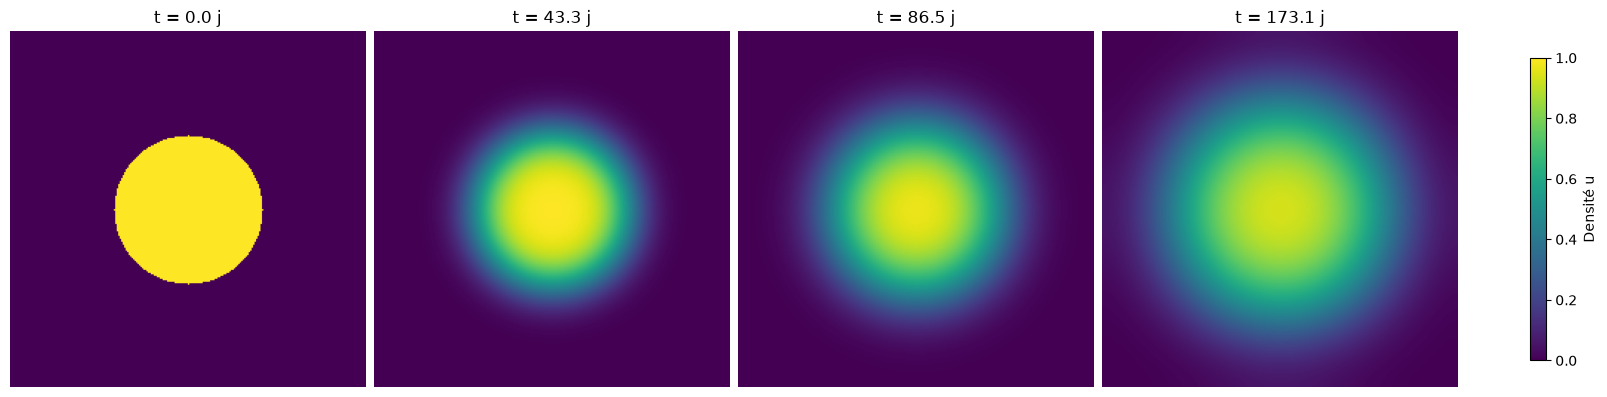

In [8]:
n_steps = grids.shape[0] - 1
indices = [0, n_steps // 4, n_steps // 2, n_steps]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for ax, idx in zip(axes, indices):
    im = ax.imshow(grids[idx], vmin=0, vmax=K_fisher, cmap="viridis")
    ax.set_title(f"t = {t_fisher[idx]:.1f} j")
    ax.axis("off")
fig.colorbar(axes[-1].images[-1], ax=axes, shrink=0.8, label="Densité u")
plt.show()

In [9]:
fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
im = ax_anim.imshow(grids[0], vmin=0, vmax=K_fisher, cmap="viridis")
ax_anim.axis("off")
title = ax_anim.set_title(f"t = {t_fisher[0]:.1f} j")

step = max(1, n_steps // 100)
frames = list(range(0, n_steps + 1, step))

def upd(i):
    im.set_data(grids[i])
    title.set_text(f"t = {t_fisher[i]:.1f} j")
    return im, title

anim = animation.FuncAnimation(fig_anim, upd, frames=frames, interval=50, blit=False)
plt.close(fig_anim)
HTML(anim.to_jshtml())

[Animation non conservée dans le fichier (trop volumineuse) : exécuter cette cellule pour la voir.]


## 3. Calibration de paramètres à partir de données bruitées

Dans un contexte réel de jumeau numérique, les paramètres cinétiques (`r`, `K`) ne sont pas connus a priori : seules des mesures bruitées du volume tumoral au cours du temps sont disponibles. Cette section illustre le schéma **modèle mécaniste + calibration sur données observées** : on génère des observations synthétiques bruitées à partir de paramètres "vrais" (inconnus du calibrateur), puis on les ré-estime par moindres carrés non linéaires (`simulation.calibration.calibrate_gompertz`).

In [10]:
from simulation.calibration import calibrate_gompertz, generate_noisy_gompertz_observations

V0_true = 50.0
r_true = 0.08
K_true = 2000.0

t_obs, V_obs = generate_noisy_gompertz_observations(
    V0=V0_true, r=r_true, K=K_true, t_span=(0, 300), n_points=60,
    noise_std_rel=0.05, seed=42,
)

calibration = calibrate_gompertz(t_obs, V_obs, V0=V0_true)

print(f"r vrai = {r_true:.4f}  |  r estimé = {calibration.r:.4f} ± {calibration.r_std_err:.4f}")
print(f"K vrai = {K_true:.1f}  |  K estimé = {calibration.K:.1f} ± {calibration.K_std_err:.1f}")
print(f"Convergence de l'optimiseur : {calibration.success}")

r vrai = 0.0800  |  r estimé = 0.0777 ± 0.0020
K vrai = 2000.0  |  K estimé = 2013.7 ± 10.2
Convergence de l'optimiseur : True


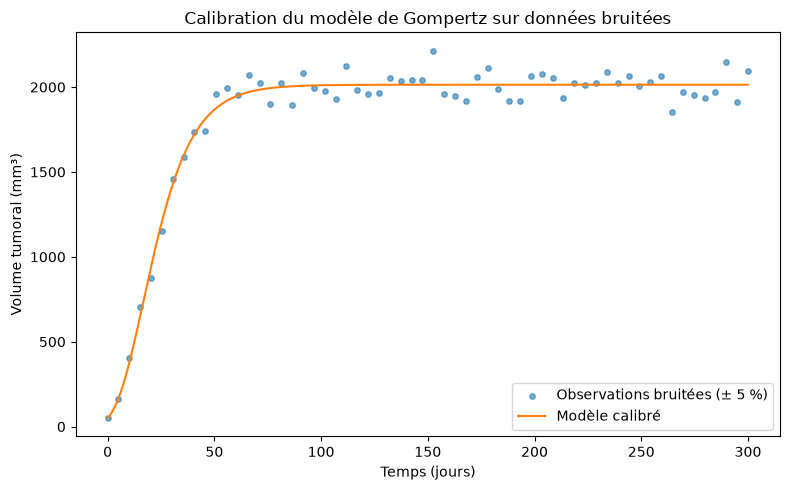

In [11]:
t_fit, V_fit = simulate(V0=V0_true, r=calibration.r, K=calibration.K, t_span=(0, 300), n_points=300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_obs, V_obs, s=15, alpha=0.6, label="Observations bruitées (± 5 %)")
ax.plot(t_fit, V_fit, color="C1", label="Modèle calibré")
ax.set_xlabel("Temps (jours)")
ax.set_ylabel("Volume tumoral (mm³)")
ax.set_title("Calibration du modèle de Gompertz sur données bruitées")
ax.legend()
fig.tight_layout()
plt.show()

### Limites

Cette calibration est faite sur des données **synthétiques** générées par le modèle lui-même (bruit ajouté artificiellement) : elle valide que la méthode d'estimation fonctionne, mais ne remplace pas une calibration sur de vraies données de bioproduction, où le modèle mécaniste lui-même peut être imparfait (erreur de structure, pas seulement bruit de mesure).

## 4. Calibration du modèle Fisher-KPP (spatial)

Même principe que pour Gompertz, mais appliqué au modèle spatial : D et r ne sont pas connus a priori, seule une observable bruitée dérivée de la grille l'est. On utilise ici la **masse tumorale totale** (intégrale de la densité sur la grille), plutôt que le rayon effectif du front vu en section 2.

Ce choix n'est pas anodin : le rayon effectif est calculé à partir d'un seuil (u > K/2), une fonction en escalier des paramètres — deux valeurs de D très proches peuvent donner exactement le même nombre de cellules au-dessus du seuil, donc un gradient numérique nul, ce qui bloque un optimiseur par gradient dès la première itération. La masse totale, elle, varie continûment avec D et r et se calibre normalement.

In [12]:
from simulation.calibration import calibrate_fisher_kpp, generate_noisy_fisher_kpp_observations

D_true = 0.005
r_true_2d = 0.05
K_2d = 1.0
grid_size_calib = 50
position_calib = (25, 25)
radius_calib = 3
n_steps_calib = 150

t_obs_2d, mass_obs = generate_noisy_fisher_kpp_observations(
    grid_size=grid_size_calib, D=D_true, r=r_true_2d, K=K_2d,
    initial_tumor_position=position_calib, initial_radius=radius_calib, n_steps=n_steps_calib,
    noise_std_rel=0.05, seed=42,
)

calibration_2d = calibrate_fisher_kpp(
    t_obs_2d, mass_obs, grid_size=grid_size_calib, K=K_2d,
    initial_tumor_position=position_calib, initial_radius=radius_calib, n_steps=n_steps_calib,
)

print(f"D vrai = {D_true:.4f}  |  D estimé = {calibration_2d.D:.4f} ± {calibration_2d.D_std_err:.4f}")
print(f"r vrai = {r_true_2d:.4f}  |  r estimé = {calibration_2d.r:.4f} ± {calibration_2d.r_std_err:.4f}")
print(f"Convergence de l'optimiseur : {calibration_2d.success}")

D vrai = 0.0050  |  D estimé = 0.0058 ± 0.0011
r vrai = 0.0500  |  r estimé = 0.0460 ± 0.0047
Convergence de l'optimiseur : True


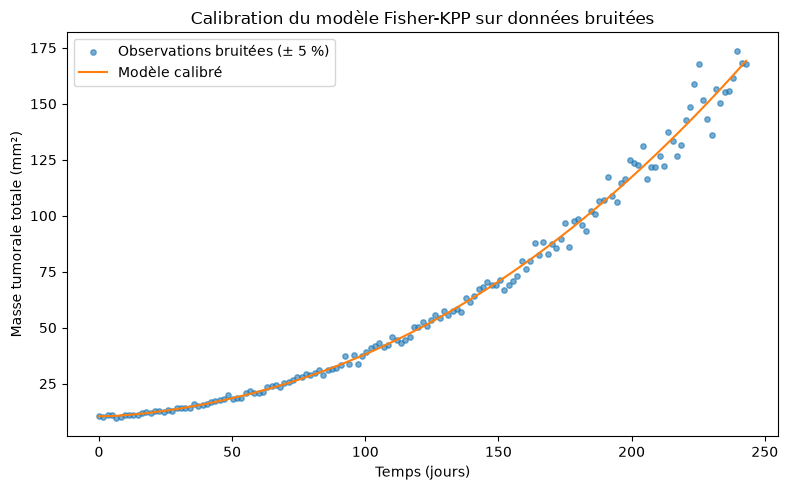

In [13]:
import simulation.diffusion_reaction as dr2

dt_calib = t_obs_2d[1] - t_obs_2d[0]
result_fit = dr2.simulate_2d(
    grid_size_calib, calibration_2d.D, calibration_2d.r, K_2d,
    position_calib, radius_calib, n_steps_calib, dt=dt_calib,
)
mass_fit = np.array([np.sum(g) for g in result_fit.grids]) * result_fit.dx**2

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_obs_2d, mass_obs, s=15, alpha=0.6, label="Observations bruitées (± 5 %)")
ax.plot(t_obs_2d, mass_fit, color="C1", label="Modèle calibré")
ax.set_xlabel("Temps (jours)")
ax.set_ylabel("Masse tumorale totale (mm²)")
ax.set_title("Calibration du modèle Fisher-KPP sur données bruitées")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Surrogate model (PyTorch) vs calibration classique

Dernière étape : remplacer la boucle d'optimisation par moindres carrés par un petit réseau de neurones entraîné sur des milliers d'exemples synthétiques, qui prédit directement les paramètres à partir d'une courbe observée, sans aucune nouvelle simulation. On compare les deux approches, sur les deux modèles, en précision **et** en temps de calcul — plutôt que de supposer que le deep learning est la meilleure option par défaut.

In [14]:
import time
from simulation.surrogate import (
    generate_fisher_kpp_surrogate_dataset,
    generate_gompertz_surrogate_dataset,
    train_surrogate,
)
from simulation.calibration import _safe_fixed_dt

def compare_nn_vs_classical(surrogate, splits, classical_fn, n_compare=20):
    X_test = splits["X_test"][:n_compare]
    y_test = splits["y_test"][:n_compare]

    t0 = time.perf_counter()
    for _ in range(50):
        y_pred_nn = surrogate.predict(X_test)
    nn_time = (time.perf_counter() - t0) / 50

    t0 = time.perf_counter()
    y_pred_classic = np.array([classical_fn(X_test[i]) for i in range(len(X_test))])
    classic_time = time.perf_counter() - t0

    err_nn = np.abs(y_pred_nn - y_test) / np.abs(y_test)
    err_classic = np.abs(y_pred_classic - y_test) / np.abs(y_test)
    return dict(
        nn_time_ms=nn_time * 1000, classic_time_ms=classic_time * 1000,
        err_nn=err_nn.mean(axis=0), err_classic=err_classic.mean(axis=0),
        speedup=classic_time / nn_time,
    )

### Gompertz

In [15]:
from simulation.calibration import calibrate_gompertz as _calib_gompertz

ds_gompertz = generate_gompertz_surrogate_dataset(
    n_samples=1500, V0=50.0, r_bounds=(0.02, 0.15), K_bounds=(500.0, 5000.0),
    t_span=(0, 300), n_points=60, noise_std_rel=0.05, seed=0,
)
surrogate_gompertz, splits_gompertz = train_surrogate(ds_gompertz, epochs=150, seed=0)
t_obs_compare = np.linspace(0, 300, 60)

def _classical_gompertz(curve):
    res = _calib_gompertz(t_obs_compare, curve, V0=50.0)
    return [res.r, res.K]

comparison_gompertz = compare_nn_vs_classical(surrogate_gompertz, splits_gompertz, _classical_gompertz)
print(f"Réseau     : {comparison_gompertz['nn_time_ms']:.3f} ms  |  erreur moyenne r={comparison_gompertz['err_nn'][0]:.1%} K={comparison_gompertz['err_nn'][1]:.1%}")
print(f"Classique  : {comparison_gompertz['classic_time_ms']:.1f} ms  |  erreur moyenne r={comparison_gompertz['err_classic'][0]:.1%} K={comparison_gompertz['err_classic'][1]:.1%}")
print(f"Facteur de vitesse (réseau / classique) : {comparison_gompertz['speedup']:.0f}x")

Réseau     : 0.270 ms  |  erreur moyenne r=5.1% K=3.0%
Classique  : 3367.4 ms  |  erreur moyenne r=2.1% K=0.7%
Facteur de vitesse (réseau / classique) : 12450x


### Fisher-KPP

In [16]:
from simulation.calibration import calibrate_fisher_kpp as _calib_fisher_kpp

grid_size_surr, K_surr, position_surr, radius_surr, n_steps_surr = 40, 1.0, (20, 20), 3, 100

ds_fisher = generate_fisher_kpp_surrogate_dataset(
    n_samples=1200, grid_size=grid_size_surr, K=K_surr, initial_tumor_position=position_surr,
    initial_radius=radius_surr, n_steps=n_steps_surr, D_bounds=(0.001, 0.02), r_bounds=(0.02, 0.1),
    noise_std_rel=0.05, seed=0,
)
surrogate_fisher, splits_fisher = train_surrogate(ds_fisher, epochs=150, seed=0)
dt_compare = _safe_fixed_dt(grid_size_surr, 0.05)
t_obs_compare_2d = np.arange(n_steps_surr + 1) * dt_compare

def _classical_fisher(curve):
    res = _calib_fisher_kpp(
        t_obs_compare_2d, curve, grid_size=grid_size_surr, K=K_surr,
        initial_tumor_position=position_surr, initial_radius=radius_surr, n_steps=n_steps_surr,
    )
    return [res.D, res.r]

comparison_fisher = compare_nn_vs_classical(surrogate_fisher, splits_fisher, _classical_fisher)
print(f"Réseau     : {comparison_fisher['nn_time_ms']:.3f} ms  |  erreur moyenne D={comparison_fisher['err_nn'][0]:.1%} r={comparison_fisher['err_nn'][1]:.1%}")
print(f"Classique  : {comparison_fisher['classic_time_ms']:.1f} ms  |  erreur moyenne D={comparison_fisher['err_classic'][0]:.1%} r={comparison_fisher['err_classic'][1]:.1%}")
print(f"Facteur de vitesse (réseau / classique) : {comparison_fisher['speedup']:.0f}x")

Réseau     : 0.198 ms  |  erreur moyenne D=34.4% r=15.4%
Classique  : 7624.5 ms  |  erreur moyenne D=30.0% r=18.8%
Facteur de vitesse (réseau / classique) : 38556x


### Ce que montre la comparaison

- **Fisher-KPP** : précision comparable entre les deux méthodes (le réseau fait même légèrement mieux sur `r`), mais le réseau est plusieurs dizaines de milliers de fois plus rapide — chaque calibration classique doit re-simuler la grille 2D à chaque itération de l'optimiseur, ce qui coûte cher. C'est le cas où le surrogate a un intérêt réel : remplacer un calcul coûteux répété par un modèle entraîné une fois.
- **Gompertz** : le réseau reste très rapide, mais la méthode classique est nettement plus précise (l'ODE se résout vite et précisément, donc les moindres carrés convergent vers une solution de meilleure qualité). Pour ce modèle, privilégier la calibration classique quand la précision prime ; le réseau reste une option si l'on doit traiter un très grand nombre de courbes d'un coup.

Cette asymétrie n'était pas garantie a priori — elle a été mesurée, pas supposée.

## Conclusion et pistes futures

- Le modèle de Gompertz capture bien la saturation de la croissance à l'échelle du volume.
- Le modèle de Fisher-KPP montre un front qui progresse à vitesse cohérente avec la théorie.
- La calibration par moindres carrés permet de retrouver les paramètres cinétiques des deux modèles à partir d'observations bruitées, avec une estimation de l'incertitude — en choisissant une observable adaptée à l'optimisation par gradient (masse totale plutôt que rayon via seuil pour Fisher-KPP).
- Un surrogate PyTorch offre une précision comparable à la calibration classique pour Fisher-KPP (en étant des dizaines de milliers de fois plus rapide), mais une précision inférieure pour Gompertz — un résultat mesuré, pas supposé, qui illustre que le deep learning n'est pas systématiquement la meilleure option.

Pistes : coupler Gompertz et Fisher-KPP, ajouter de nouveaux modèles via `TumorGrowthModel`, calibrer sur données réelles, serveur MCP.